In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler,FunctionTransformer,PowerTransformer,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('Breast_cancer_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df.drop(columns=['Unnamed: 32'],inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Successfully generated boxplots and saved to 'all_numerical_boxplots.png'


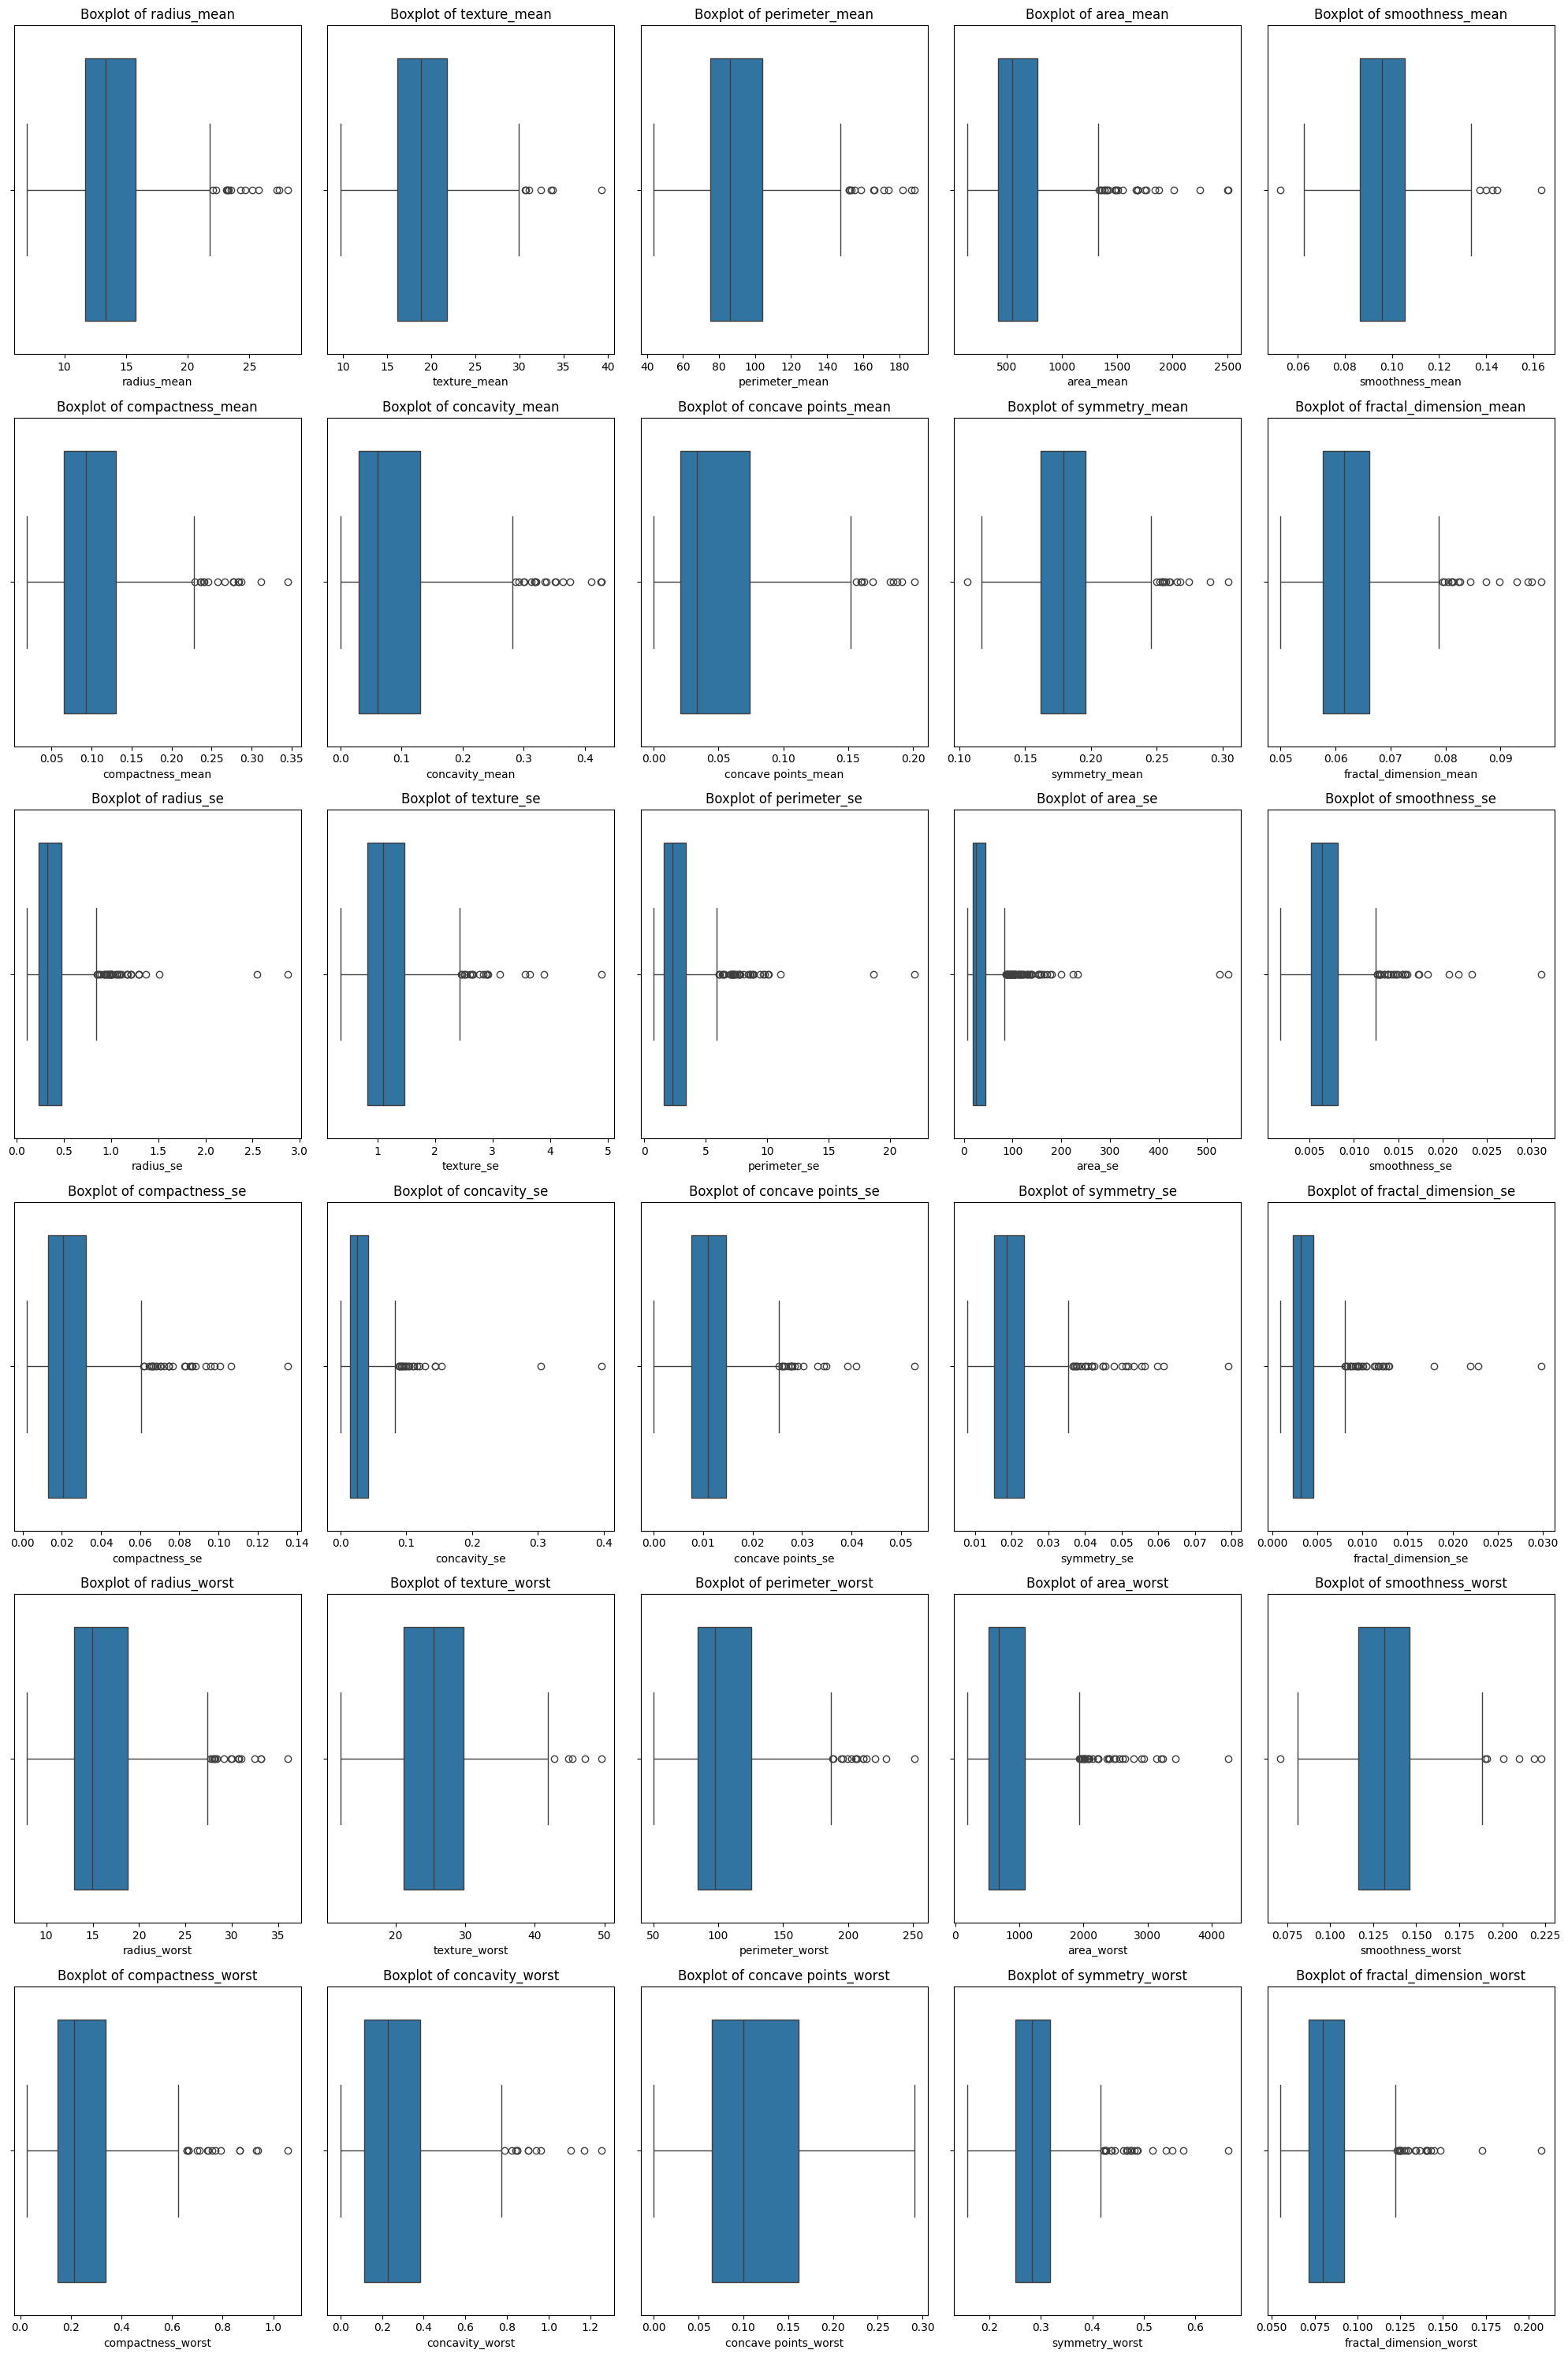

In [9]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.boxplot(x=df[col], ax=axs[plot_index])
            axs[plot_index].set_title(f'Boxplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"Successfully generated boxplots and saved to 'all_numerical_boxplots.png'")

In [10]:
# all_numerical_cols = df.select_dtypes(include=np.number).columns
# cols_to_exclude = ['id'] 
# cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]
# numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]
# for col in numerical_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
    
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
    
#     # Condition banao
#     condition = (df[col] >= lower_bound) & (df[col] <= upper_bound)

#     df = df[condition]

# print(f"Size after removing statistical outliers: {df.shape}")

Successfully generated 


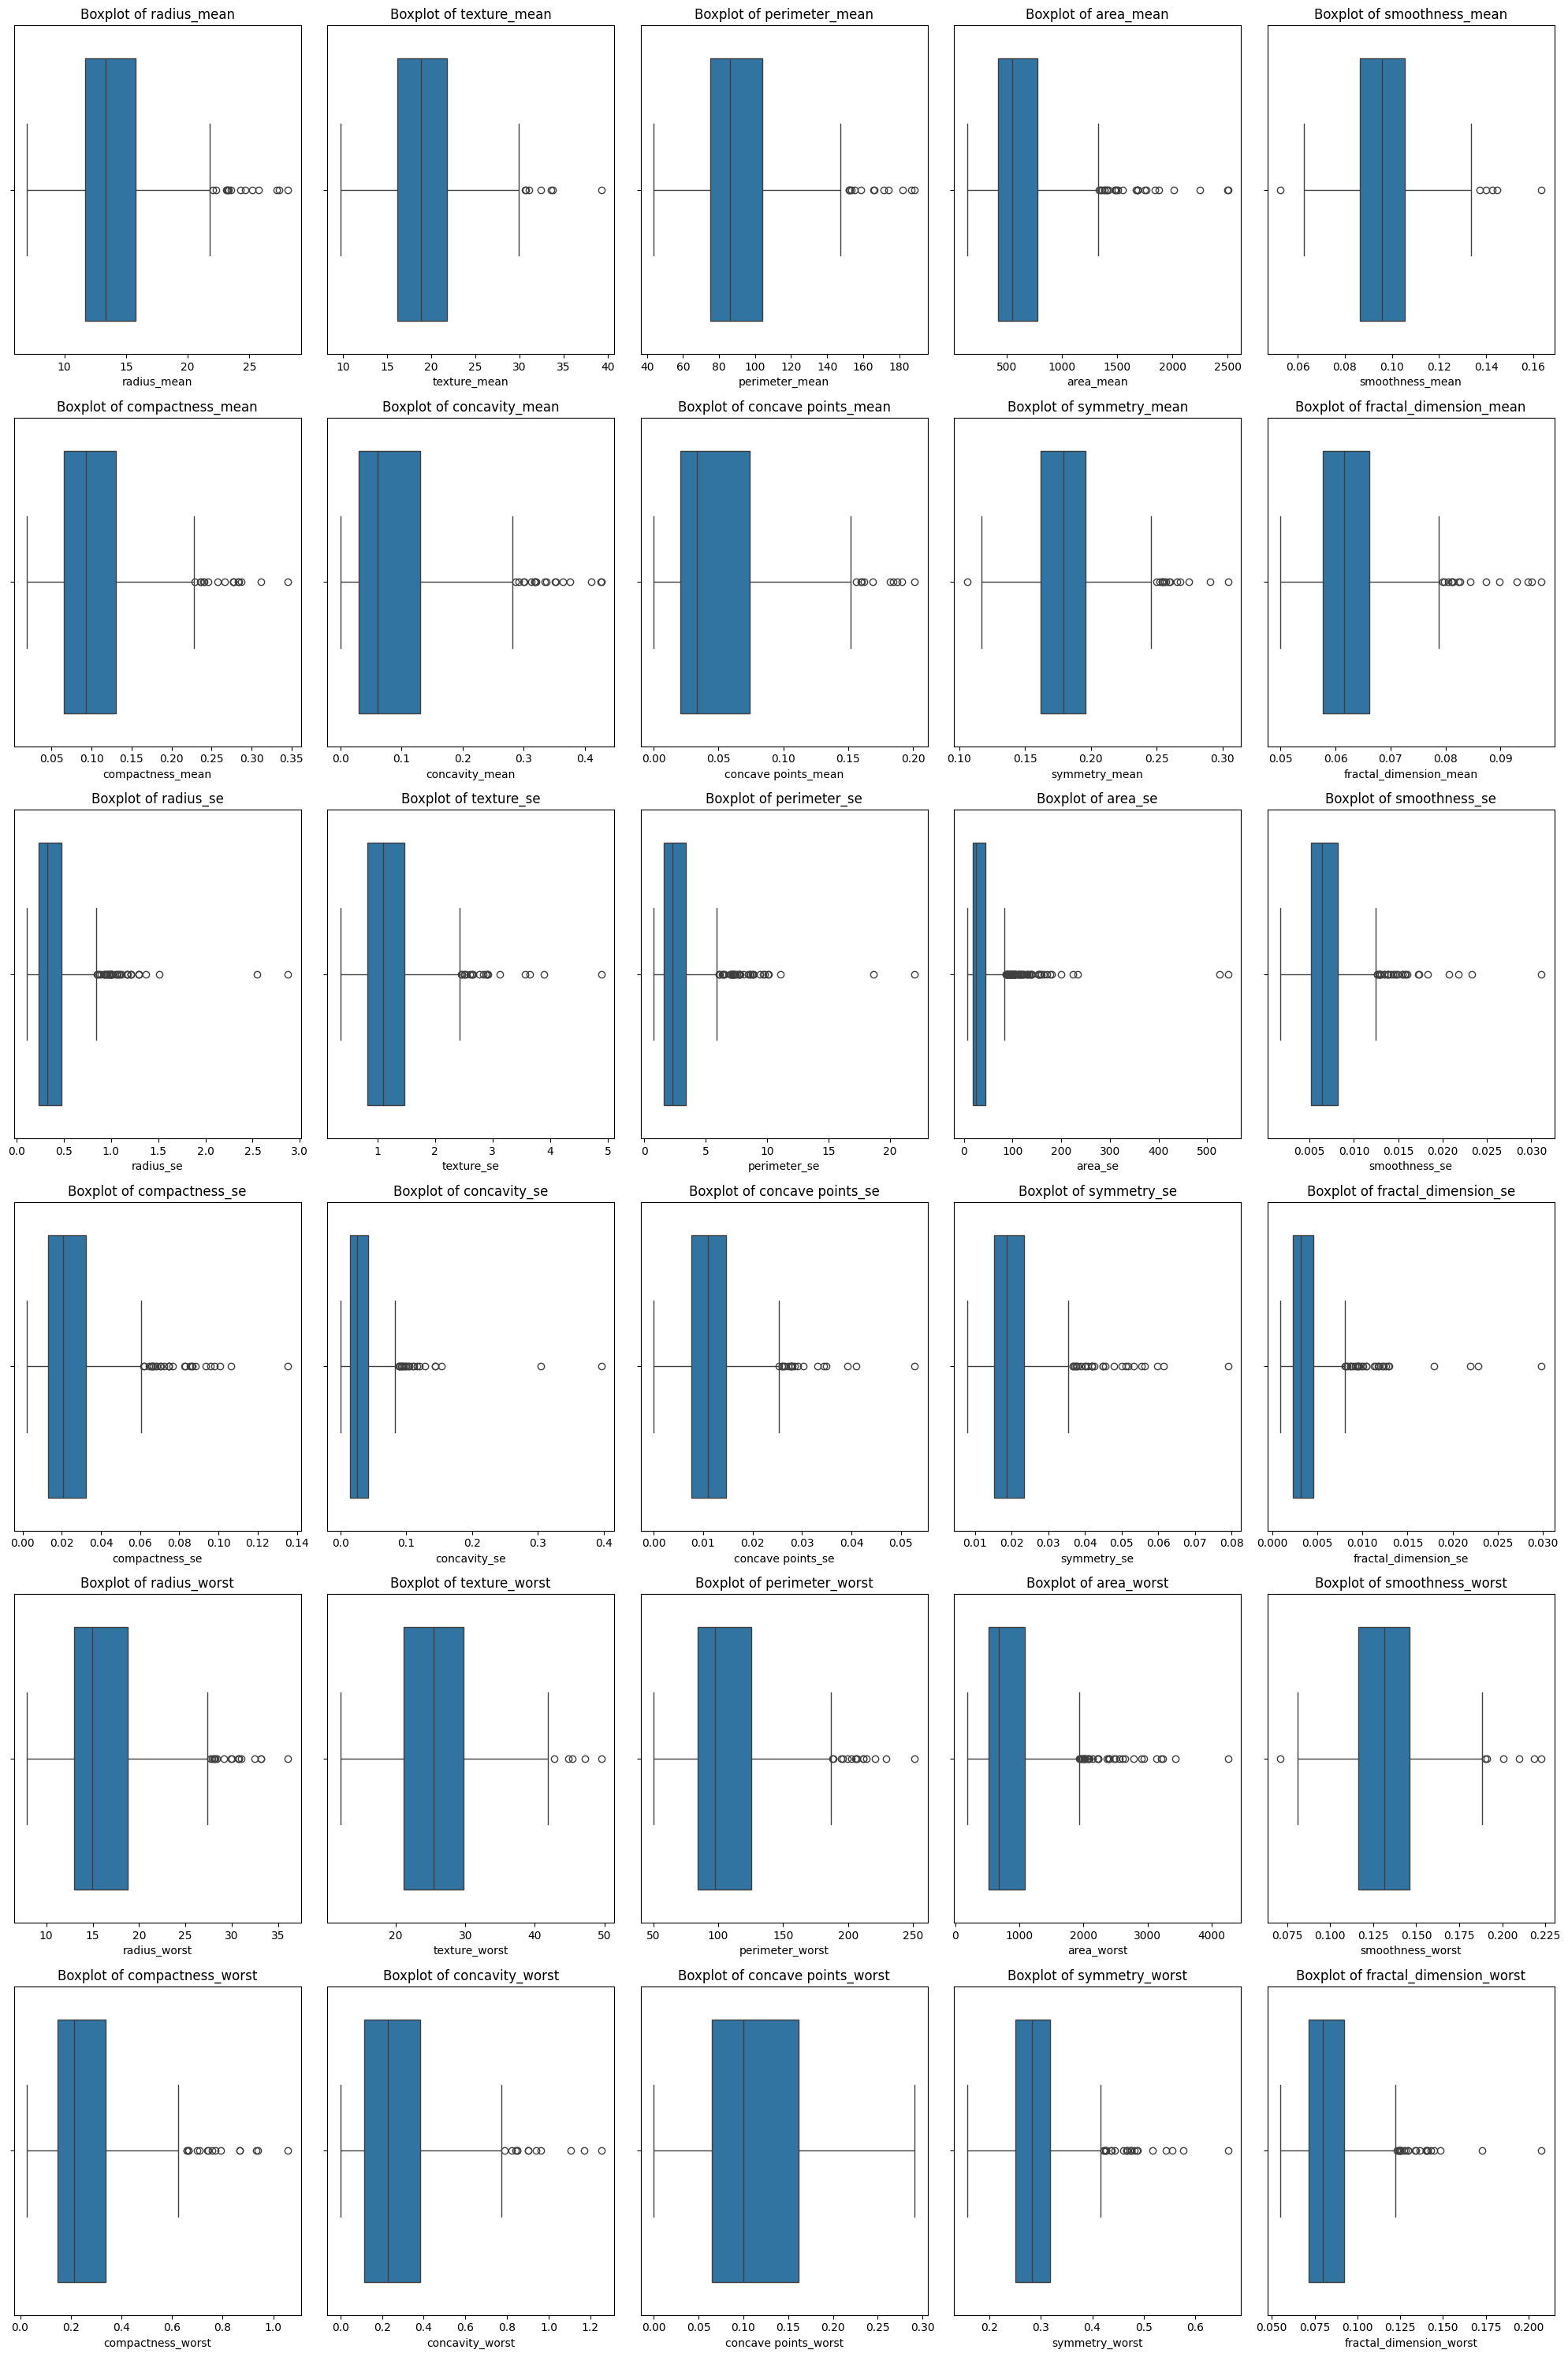

In [11]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.boxplot(x=df[col], ax=axs[plot_index])
            axs[plot_index].set_title(f'Boxplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"Successfully generated ")

before iqr 


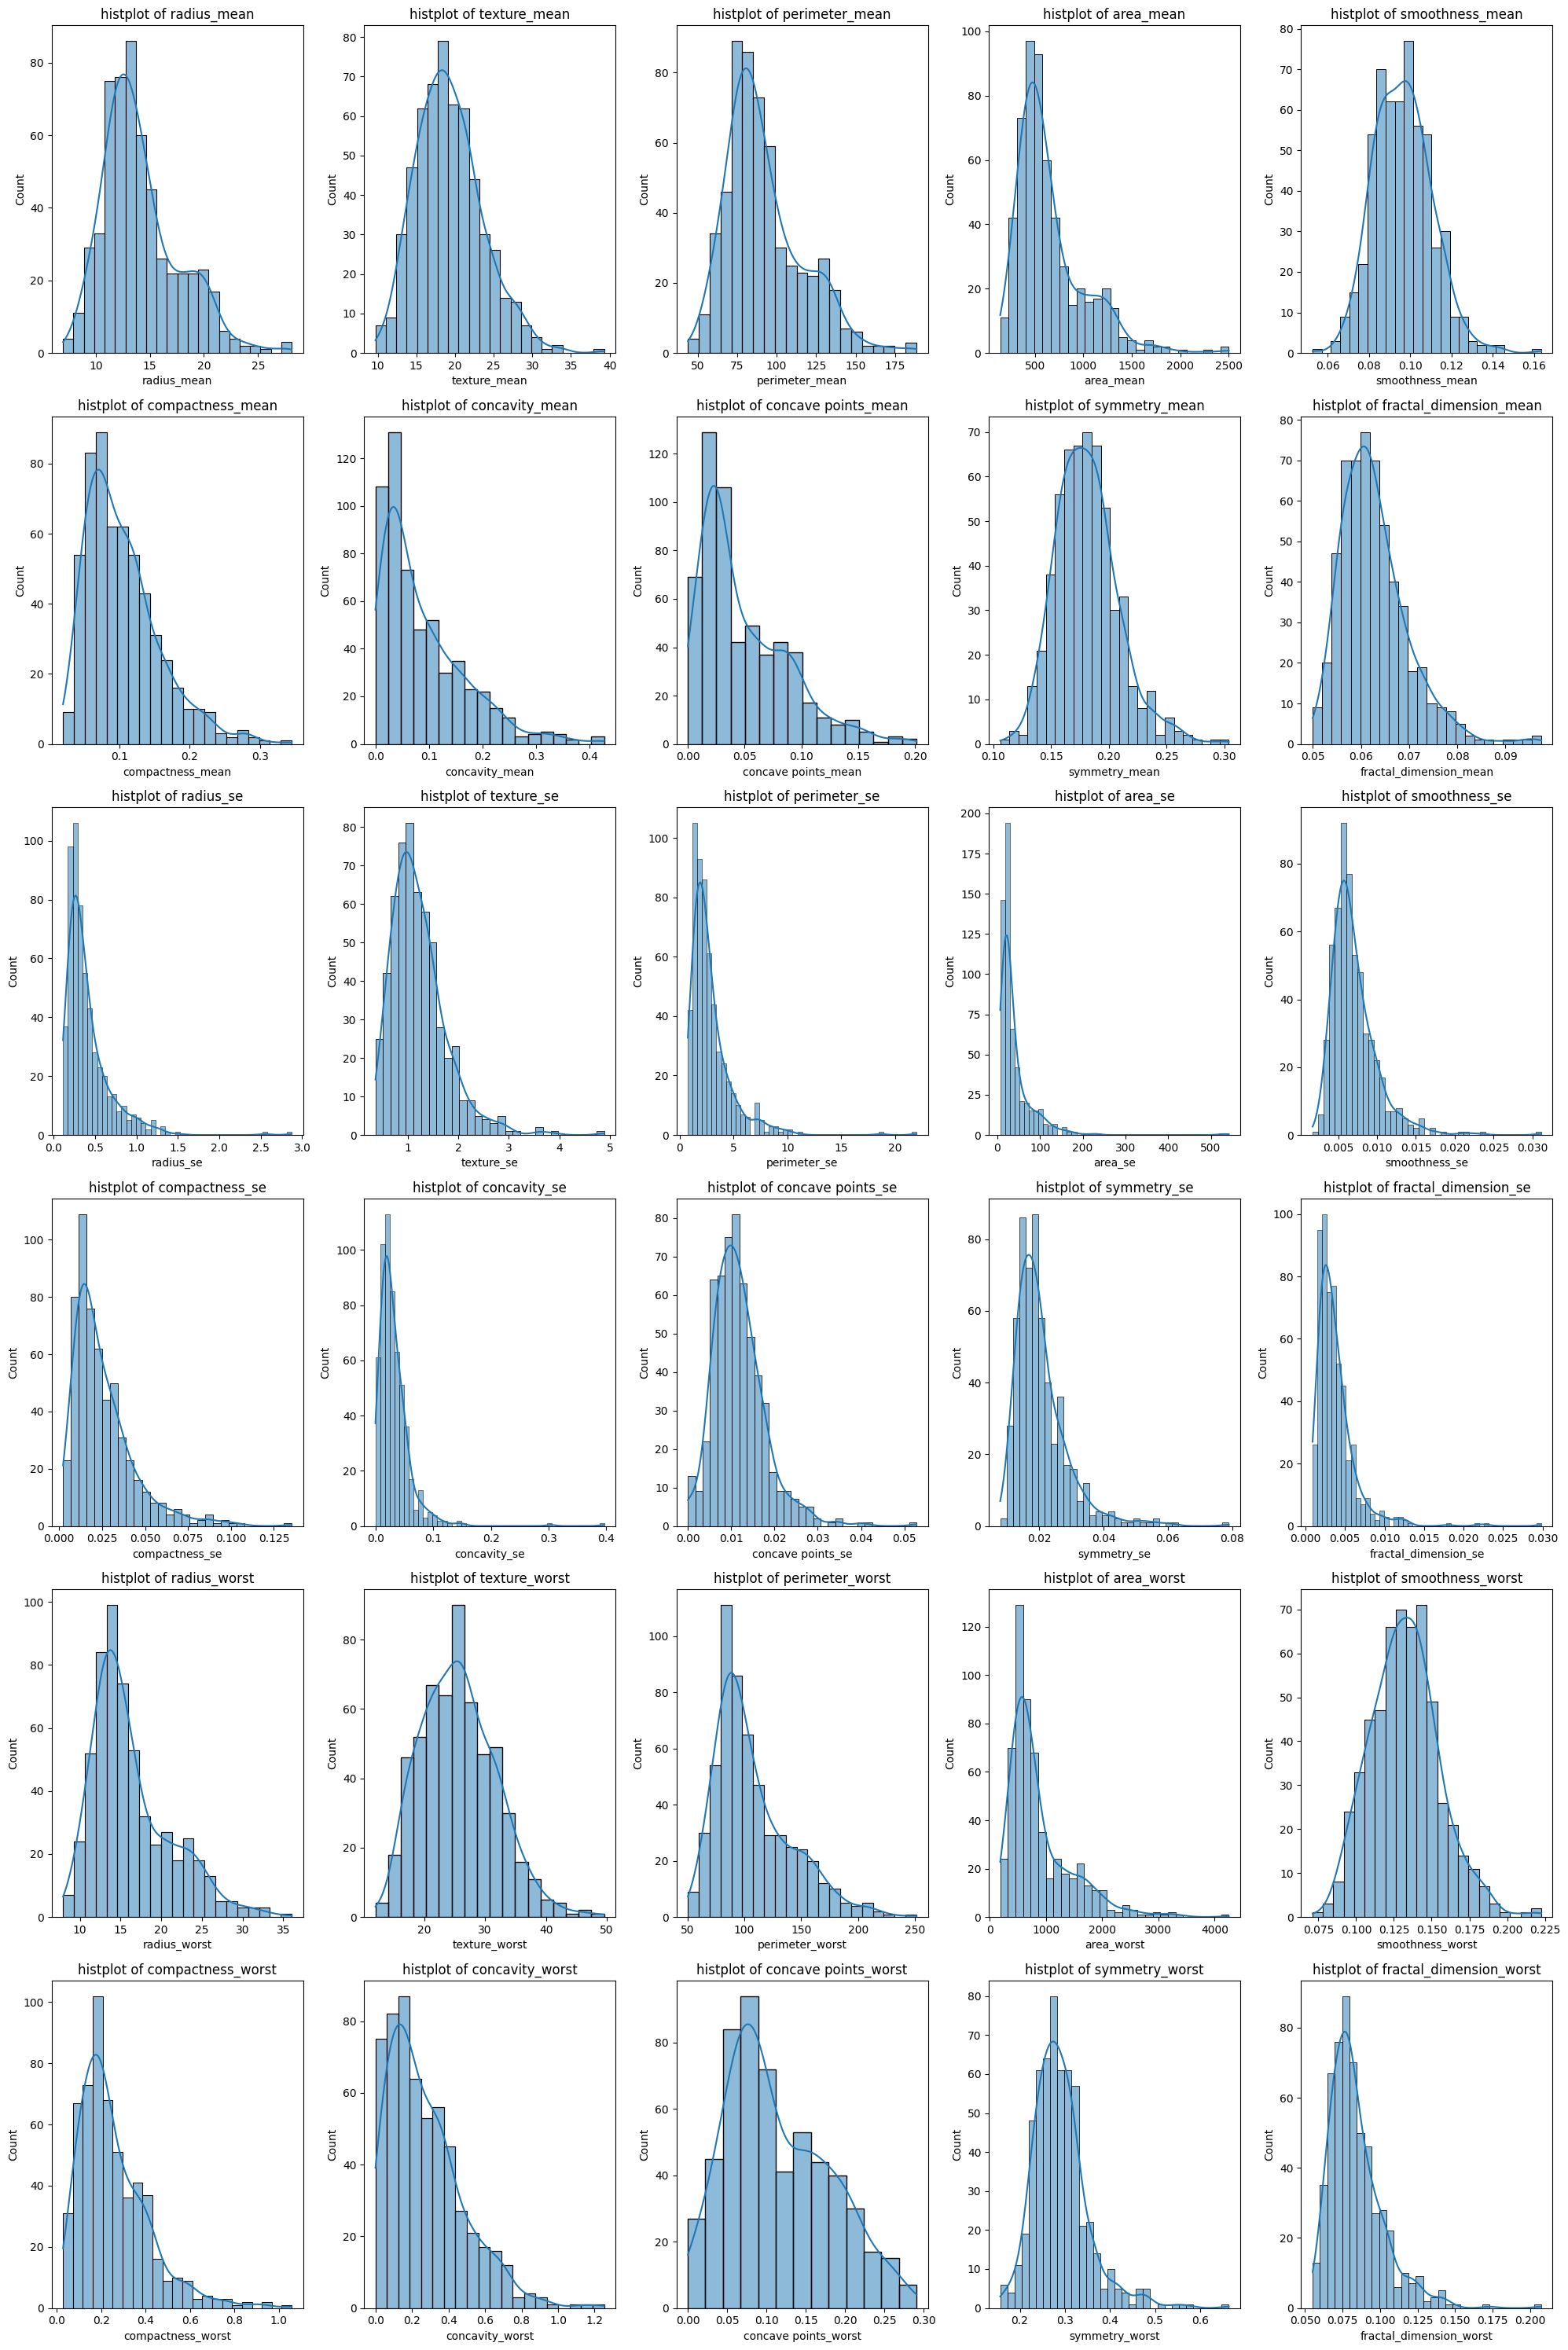

In [12]:


# Get all numerical columns from the DataFrame
all_numerical_cols = df.select_dtypes(include=np.number).columns

# Define columns you want to exclude
cols_to_exclude = ['id'] 
cols_to_exclude_lower = [col.lower() for col in cols_to_exclude]

# Create the final list of columns to plot
numerical_cols = [col for col in all_numerical_cols if col.lower() not in cols_to_exclude_lower]

n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    # --- UPDATED LOOP LOGIC ---
    plot_index = 0 # Use a separate index for placing plots on the axes
    for col in numerical_cols:
        
        # This check prevents the error:
        # Only plot if the column has at least one non-NaN value
        if df[col].notna().any():
            sns.histplot(x=df[col], ax=axs[plot_index],kde=True)
            axs[plot_index].set_title(f'histplot of {col}')
            plot_index += 1 # Only advance the plot index if we made a plot
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")
    # --- END OF UPDATED LOGIC ---

    # Hide any unused subplots
    # Use 'plot_index' to know where the valid plots stopped
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    print(f"before iqr ")

In [13]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [14]:
df['diagnosis'].nunique()

2

In [15]:
le= LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])

In [16]:
X = df.drop('diagnosis',axis=1)
y = df['diagnosis']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) 

In [17]:
transform= ColumnTransformer(transformers=[
    ('power',PowerTransformer(method='yeo-johnson'),['compactness_mean', 'concavity_mean','concave points_mean','radius_se',
                                                      'texture_se', 'perimeter_se', 'area_se', 'smoothness_se','compactness_se', 
                                                      'concavity_se', 'concave points_se', 'symmetry_se','fractal_dimension_se',
                                                      'perimeter_worst', 'area_worst','compactness_worst', 'concavity_worst','fractal_dimension_worst'])
],remainder='passthrough')

In [18]:
X_train_trans=transform.fit_transform(X_train)
X_test_trans=transform.transform(X_test)


In [19]:
X_train_trans=pd.DataFrame(X_train_trans).head()

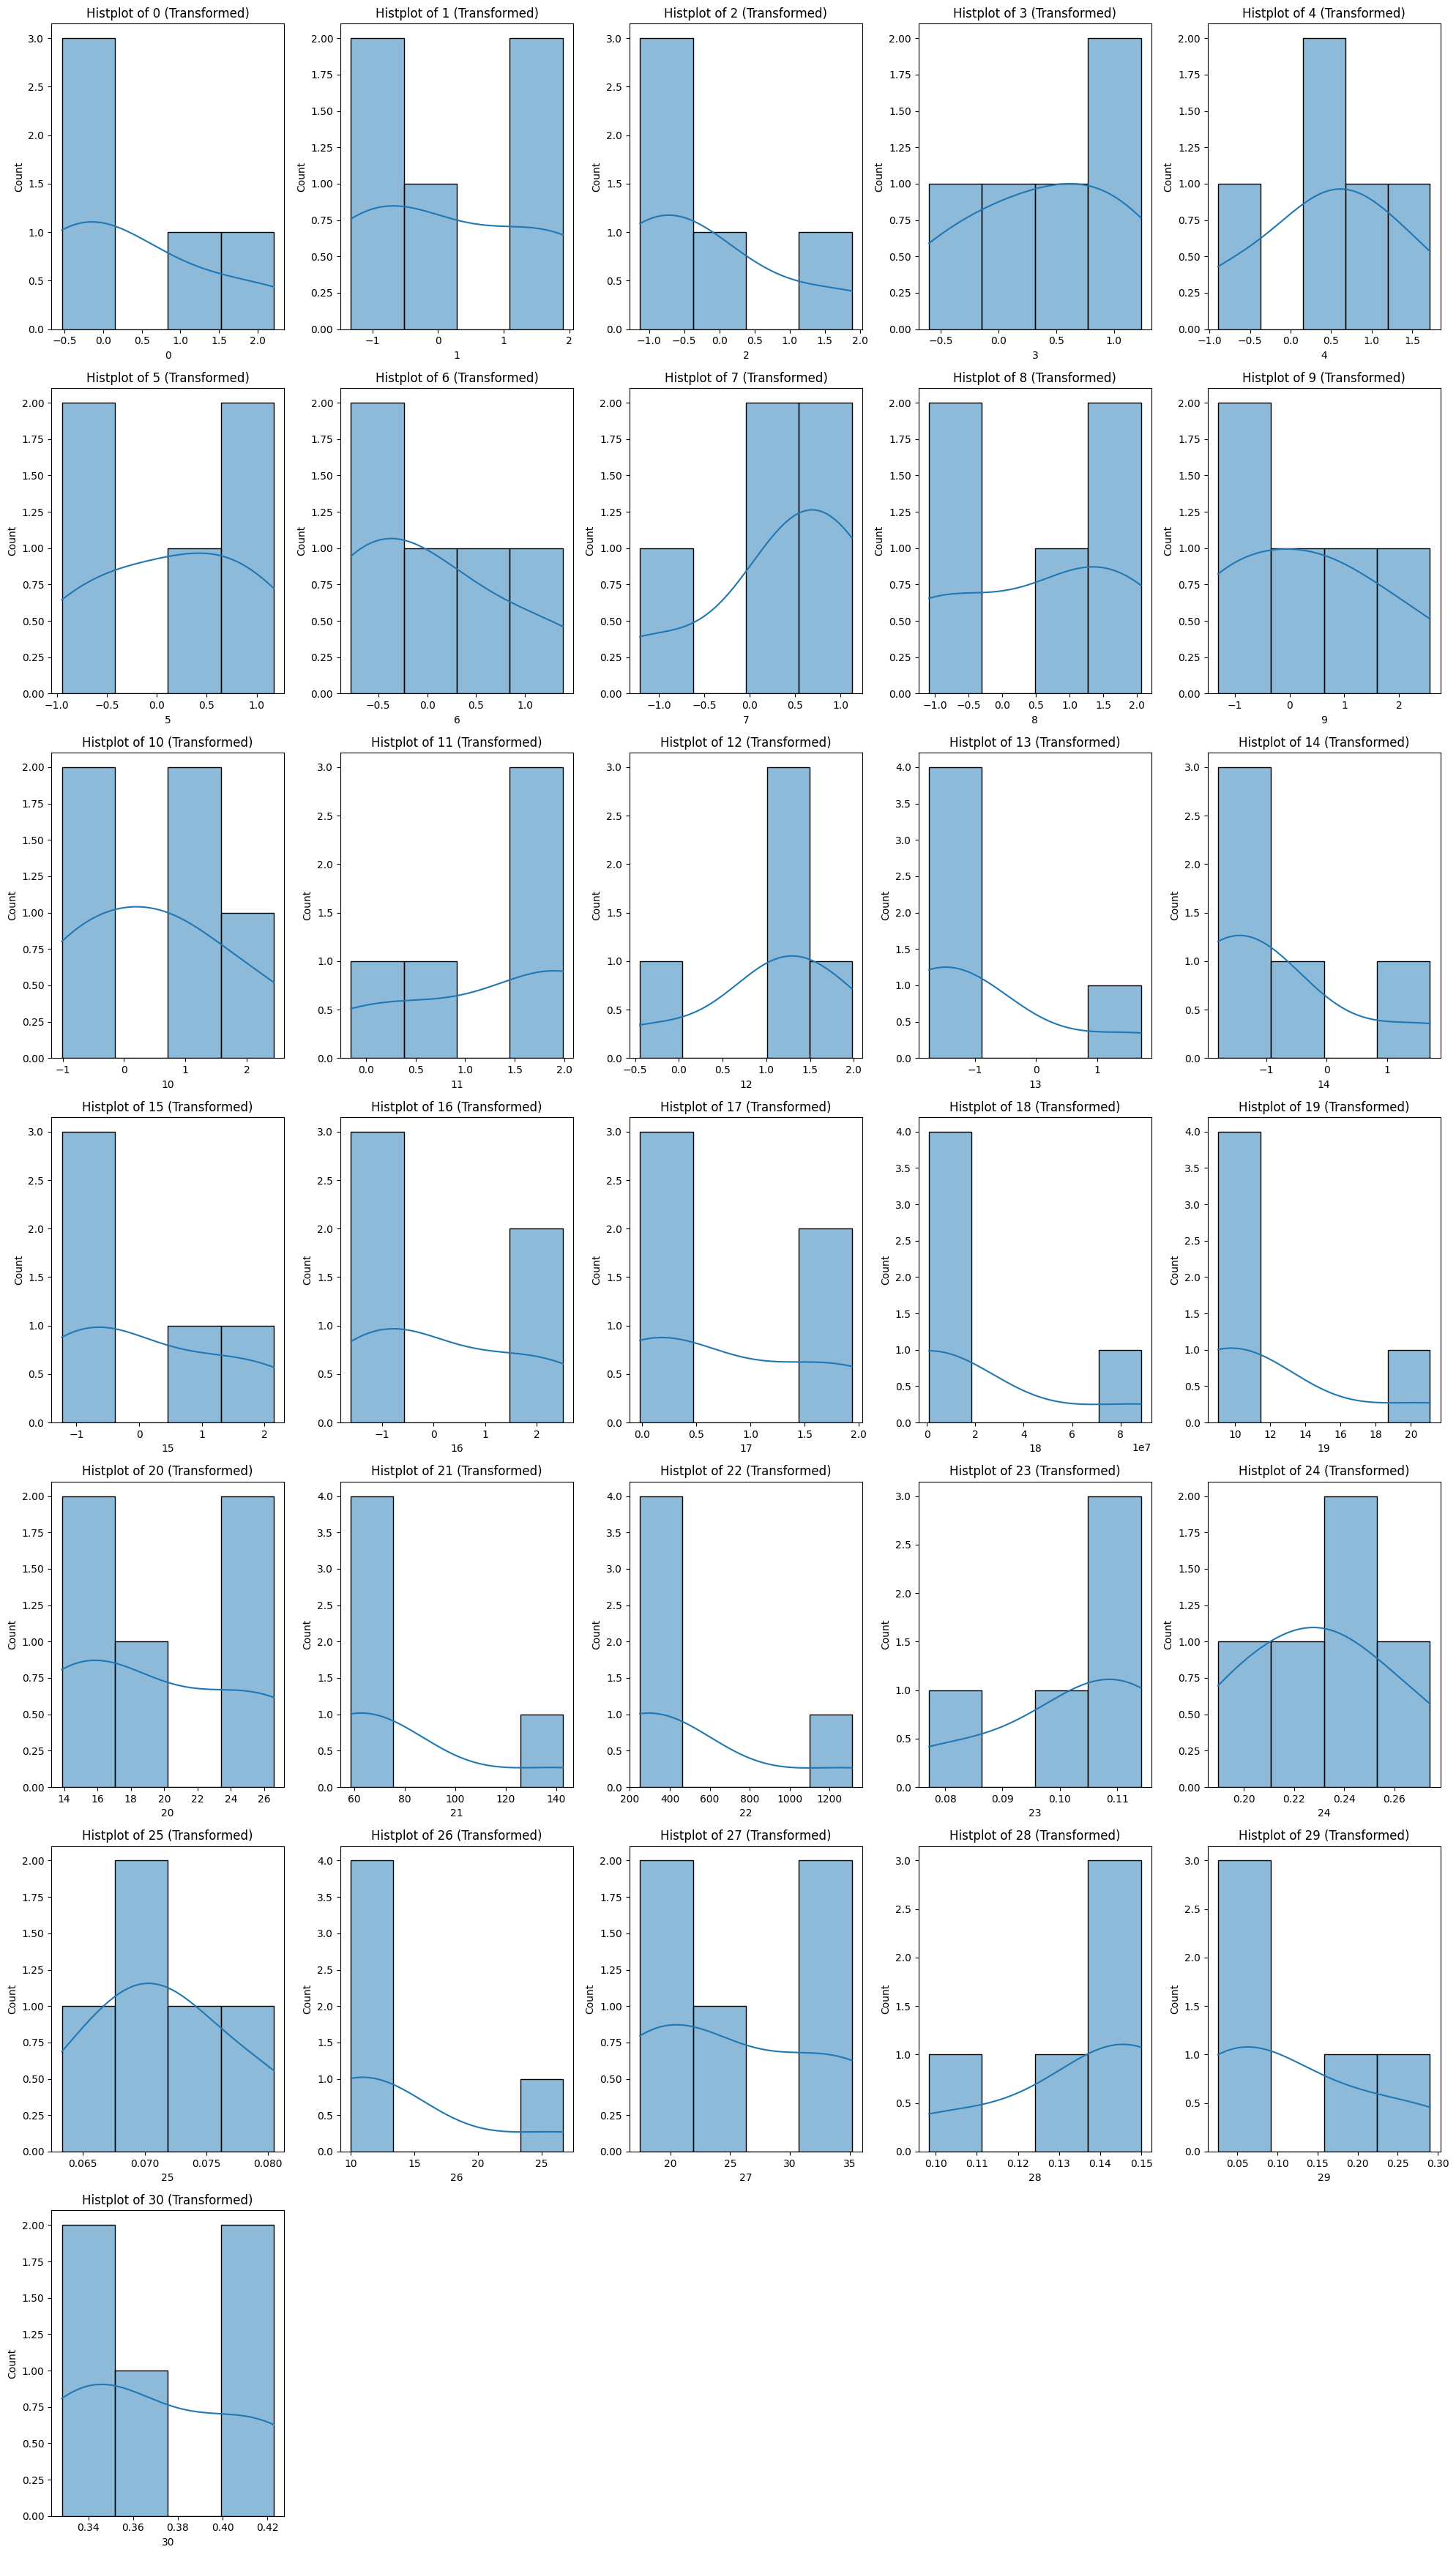

after iqr


In [20]:
all_numerical_cols = X_train_trans.select_dtypes(include=np.number).columns

numerical_cols = all_numerical_cols 
n_cols_to_plot = len(numerical_cols)

if n_cols_to_plot == 0:
    print("No numerical columns found to plot (after exclusions).")
else:
    ncols = 5
    nrows = (n_cols_to_plot + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), squeeze=False)
    axs = axs.flatten()

    plot_index = 0 
    for col in numerical_cols:
        
        # Check for NaNs in the transformed data
        if X_train_trans[col].notna().any():
            
            # --- FIX 2: Plot from X_train_trans[col], not df[col] ---
            # This fixes the "KeyError: 0"
            sns.histplot(x=X_train_trans[col], ax=axs[plot_index], kde=True)
            
            axs[plot_index].set_title(f'Histplot of {col} (Transformed)')
            plot_index += 1 
        else:
            print(f"Skipping '{col}': Column contains only NaN values.")

    # Hide any unused subplots
    for i in range(plot_index, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    
    plt.show()
    
    print(f"after iqr")
    

In [21]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('le', LogisticRegression(max_iter=10000,random_state=42))
])

In [22]:
pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('le', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:
y_pred_train_pipeline = pipeline.predict(X_train)
y_pred_test_pipeline = pipeline.predict(X_test)

y_pred_probability= pipeline.predict_proba(X_test)[:,1]

In [24]:
result_df= pd.DataFrame({'Actual':y_test,'Predicted':y_pred_test_pipeline,"predicted_probab":y_pred_probability})
result_df

,Actual,Predicted,predicted_probab
204,0,0,0.111077
70,1,1,0.999991
131,1,1,0.996797
431,0,0,0.000458
540,0,0,0.000050
...,...,...,...
486,0,0,0.031861
75,1,1,0.999234
249,0,0,0.001268
238,0,1,0.539394


In [25]:

# --- PLOT 2: Sigmoid Curve Plot ---
plt.figure(figsize=(10, 7))
    
# Add jitter for better visibility
y_jittered = y_1d + np.random.normal(0, 0.03, size=len(y_1d))
plt.scatter(X_1d_scaled, y_jittered, alpha=0.3, label='Actual Data (with jitter)')

    # Create the S-curve
x_range = np.linspace(X_1d_scaled.min(), X_1d_scaled.max(), 200).reshape(-1, 1)
y_proba = model_1d.predict_proba(x_range)[:, 1]

plt.plot(x_range, y_proba, color='red', linewidth=3, label='Logistic Regression Curve')
plt.title('1-Feature Logistic Regression (radius_mean)')
plt.xlabel('Scaled radius_mean')
plt.ylabel('Probability of Malignant (Class 1)')
plt.yticks([0, 0.5, 1], labels=['Benign (0)', '0.5', 'Malignant (1)'])
plt.legend()
plt.grid(True)



# This 'except' block will catch the file error
except FileNotFoundError:
print("\n--- ERROR ---")
print("Error: 'Breast_cancer_dataset.csv' not found.")
print("Please upload the file and run this entire cell again.")
except Exception as e:
print(f"An unexpected error occurred: {e}")

SyntaxError: invalid syntax (2215535953.py, line 23)